# World Cup Performance Analysis and Prediction

<b>Testing dataset suitability for regression:</b> 

count    616.000000
mean      12.183442
std        8.002466
min        1.000000
25%        6.000000
50%       11.000000
75%       17.000000
max       32.000000
Name: WorldCup_Classification, dtype: float64


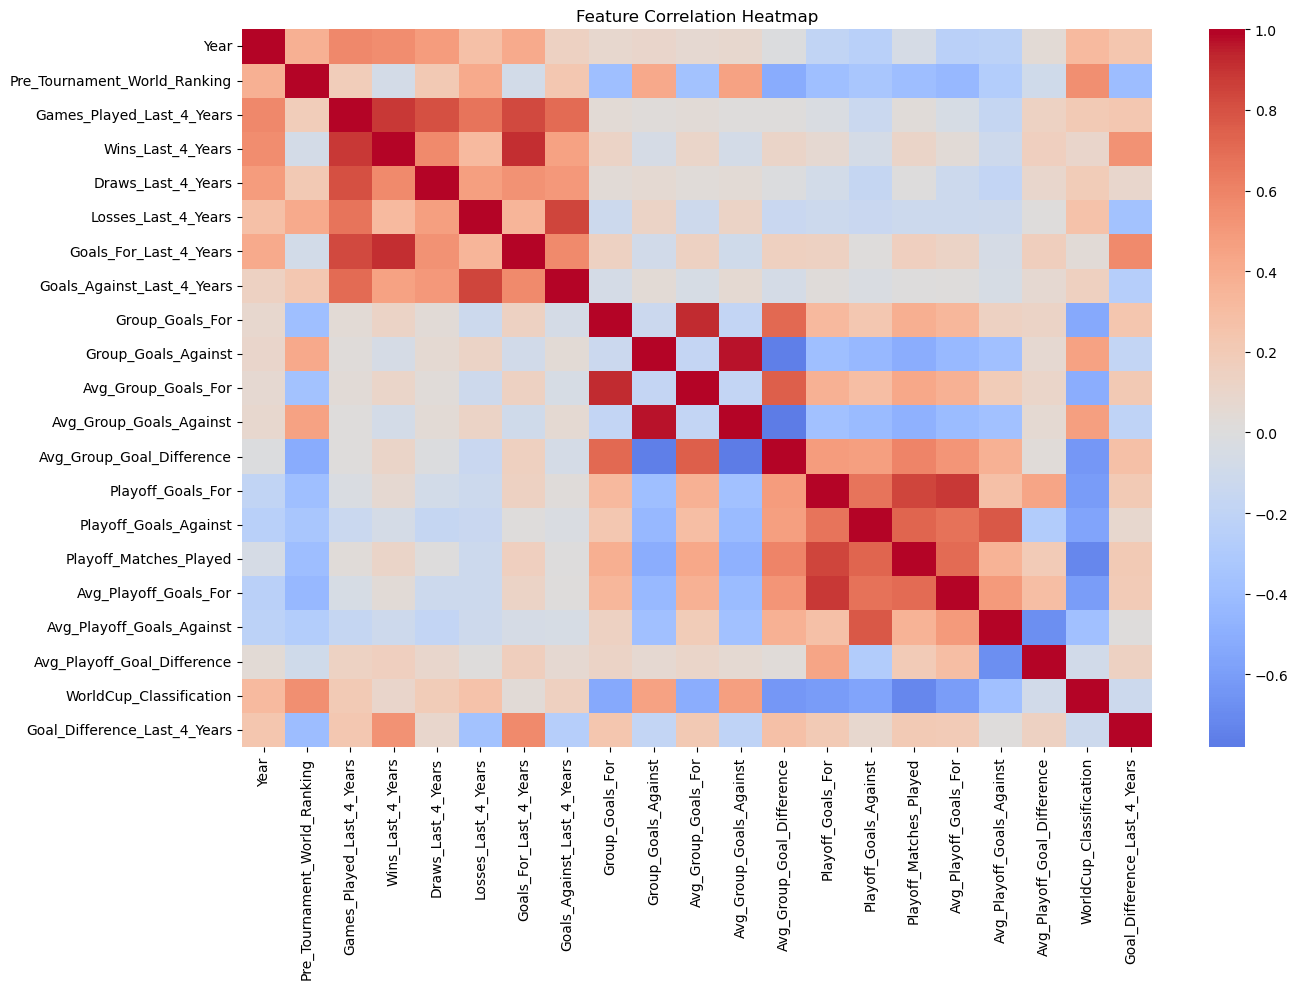

Playoff_Matches_Played         -0.721356
Avg_Group_Goal_Difference      -0.629635
Playoff_Goals_For              -0.613363
Avg_Playoff_Goals_For          -0.606040
Playoff_Goals_Against          -0.560573
Group_Goals_For                -0.530201
Avg_Group_Goals_For            -0.502915
Avg_Playoff_Goals_Against      -0.386046
Goal_Difference_Last_4_Years   -0.124762
Avg_Playoff_Goal_Difference    -0.085572
Goals_For_Last_4_Years          0.034978
Wins_Last_4_Years               0.100042
Goals_Against_Last_4_Years      0.152162
Draws_Last_4_Years              0.187919
Games_Played_Last_4_Years       0.203066
Losses_Last_4_Years             0.257234
Year                            0.313027
Group_Goals_Against             0.451037
Avg_Group_Goals_Against         0.464906
Pre_Tournament_World_Ranking    0.548180
WorldCup_Classification         1.000000
Name: WorldCup_Classification, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#continuous
#read csv file
data = pd.read_csv('WorldCup_Stats.csv')
#describe csv file to give numerical summary 
r=data.describe()
#print describe of worldcup_classification
print(r['WorldCup_Classification'])

#correlation
#numeric correlations to wcc and sort values, smallest to largest by default
r1=data.corr(numeric_only=True)['WorldCup_Classification'].sort_values()
#correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True), 
            annot=False, 
            cmap='coolwarm', 
            center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
#print
print(r1)

Suitable because:

- The target WorldCup_Classification shows continuous numerical values, ranging from 1 at minimum (showing winner) to 32 at maximum (showing last place).

- Using data.corr, Pre_Tournament_World_Ranking shows 0.55 and Avg_Group_Goal_Difference shows -0.63, and results close to 1 or -1 indicate high correlation to WorldCup_Classification.

- .describe() shows that the dataset has 616 data points, more than enough to find regression coefficients.

<b>Evaluating dataset quality before modelling:</b>

count    616.000000
mean      38.217532
std       15.393740
min        0.000000
25%       29.000000
50%       39.000000
75%       48.000000
max       93.000000
Name: Games_Played_Last_4_Years, dtype: float64
              Team  Year  Games_Played_Last_4_Years
257  United States  1994                         93
270  United States  1995                         88
301        Jamaica  1998                         83
338         Mexico  2002                         82


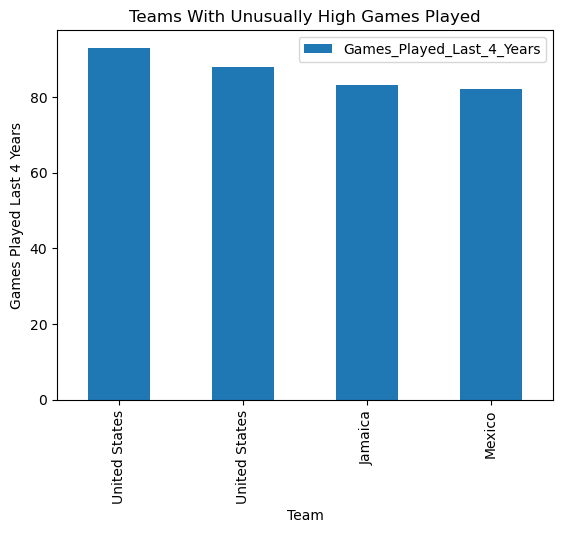

Pre_Tournament_World_Ranking    319
Goal_Difference_Last_4_Years     22
dtype: int64


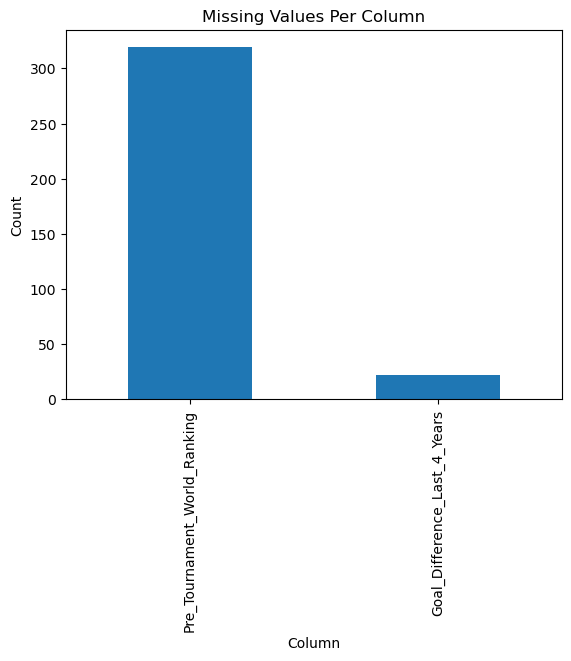

In [2]:
import matplotlib.pyplot as plt

#anomalies with much higher games played than others
#get data of overall games played over 4 years
norm = data.describe()
#print the data of games played last 4 years
print(norm['Games_Played_Last_4_Years'])
#get the teams that have played >80 games, the anomalies
anom = data[data['Games_Played_Last_4_Years'] > 80]
#prepare graph
anom = anom[['Team', 'Year', 'Games_Played_Last_4_Years']] 
#print data of teams with >80 games
print(anom)
#plot bar graph of anomalies
anom.plot(x='Team', y = 'Games_Played_Last_4_Years', kind='bar')
#graph title
plt.title('Teams With Unusually High Games Played')
#graph y axis label
plt.ylabel('Games Played Last 4 Years')
#graph x axis label
plt.xlabel('Team')
#show graph
plt.show()

#null data 
#check and add the numbers of points that are null
miss = data.isnull().sum()
#show null columns
miss = miss[miss > 0]
#print
print(miss)
#bar graph
miss.plot(kind ='bar')
#title
plt.title('Missing Values Per Column')
#y label name
plt.ylabel('Count')
#x label name
plt.xlabel('Column')
#show graph
plt.show()

- USA in 1994, USA in 1995, Jamaica in 1998 and Mexico in 2002 played an anomalistic number of games under the Games_Played_Last_4_Years column, all 4 having 80+ played when comparatively even the top 75% of teams was only 48, per describe(), showing they are clear outliers. This could alter the per game feature calculations, for example Points_Per_Game_Last_4_Years would be disproportionately low for these teams as they played far more games, which will mislead regression model coefficients.
- In the Pre_Tournament_World_Ranking column there's 319 sets of data missing and in Goal_Difference_Last_4_Years column, there's 22 sets of data missing, both put as NaN. Due to this, data could be lost and the model could fail and need preprocessing as it can't compute NaN results.

<b>Cleaning the dataset for modelling:</b> 

In [3]:
#keep identifiers for later reference
labels = data[['Team', 'Year']].copy()
#remove team and year columns
data = data.drop(columns =['Team', 'Year'])
#remove teams with >80 games played
data = data[data['Games_Played_Last_4_Years'] <= 80]
#print new numbers for games played last 4 years, showing max is now under 80
print(data['Games_Played_Last_4_Years'].describe())
#fill missing datas with median from each column
data = data.fillna(data.median(numeric_only=True)) 
#sum how much null data is in each column and print
print(data.isnull().sum())
#print the number of data points (612) and columns (22)
print(data.shape)

count    612.000000
mean      37.901961
std       14.934232
min        0.000000
25%       29.000000
50%       39.000000
75%       47.000000
max       78.000000
Name: Games_Played_Last_4_Years, dtype: float64
Team_Continent                  0
Host_Continent                  0
Pre_Tournament_World_Ranking    0
Games_Played_Last_4_Years       0
Wins_Last_4_Years               0
Draws_Last_4_Years              0
Losses_Last_4_Years             0
Goals_For_Last_4_Years          0
Goals_Against_Last_4_Years      0
Group_Goals_For                 0
Group_Goals_Against             0
Avg_Group_Goals_For             0
Avg_Group_Goals_Against         0
Avg_Group_Goal_Difference       0
Playoff_Goals_For               0
Playoff_Goals_Against           0
Playoff_Matches_Played          0
Avg_Playoff_Goals_For           0
Avg_Playoff_Goals_Against       0
Avg_Playoff_Goal_Difference     0
WorldCup_Classification         0
Goal_Difference_Last_4_Years    0
dtype: int64
(612, 22)


- Removed the team and year columns, as they're identifiers and therefore add nothing numerical for the regression model's learning.
- Removed the values that were deemed anomalous previously.
- Replaced the NaN data points by filling them with the median data from its corresponding column.
- Checks confirm the cleaning worked; max games played is now 78 from 93, no nulls remain, and the dataset went from 616×24 to 612×22.

<b>Feature engineering and categorical encoding:</b>

In [4]:
#filter out 0 games played last 4 years 
data = data[data['Games_Played_Last_4_Years'] > 0]
#points per game last 4 years
data['Points_Per_Game_Last_4_Years']=(3 * data['Wins_Last_4_Years'] + data['Draws_Last_4_Years'])/ data['Games_Played_Last_4_Years']
#goal pro last 4 years
data['Goal_Pro_Last_4_Years'] = (data['Goals_For_Last_4_Years']) / data['Games_Played_Last_4_Years']
#goals conceded last 4 years
data['Goal_Con_Last_4_Years']= (data['Goals_Against_Last_4_Years']) / data['Games_Played_Last_4_Years']
#goal diff last 4 years
data['Goal_Diff_Last_4_Years'] = (data['Goals_For_Last_4_Years'] -data['Goals_Against_Last_4_Years']) / data['Games_Played_Last_4_Years']
#check new features
print(data[['Points_Per_Game_Last_4_Years','Goal_Pro_Last_4_Years','Goal_Con_Last_4_Years','Goal_Diff_Last_4_Years']].head(10))

#copy so data can be kept
dmodel = data.copy()
#check data types before encoding
print(dmodel.dtypes)
#turn string columns to numeric columns
dmodel = pd.get_dummies(dmodel, columns=['Team_Continent', 'Host_Continent'], drop_first=True)
#check encoding worked, no null
print(dmodel.dtypes)
print(dmodel.isnull().sum())
print(dmodel.shape)
#check ranking kept variation
print(data['Pre_Tournament_World_Ranking'].unique())

    Points_Per_Game_Last_4_Years  Goal_Pro_Last_4_Years  \
0                       1.777778               2.222222   
1                       1.960000               2.880000   
2                       1.333333               3.666667   
3                       1.388889               2.166667   
4                       1.375000               2.875000   
6                       0.625000               1.500000   
7                       1.727273               2.727273   
8                       1.444444               2.333333   
9                       0.500000               0.833333   
10                      1.111111               1.851852   

    Goal_Con_Last_4_Years  Goal_Diff_Last_4_Years  
0                1.148148                1.074074  
1                0.920000                1.960000  
2                5.333333               -1.666667  
3                2.277778               -0.111111  
4                2.000000                0.875000  
6                3.541667             

- Created 4 per game features by normalising totals by matches played. Raw totals aren't comparable across teams, as one that played 50 games usually has more goals than one that played 20 without necessarily being stronger due to much more chances to score.
  
- Filtered out teams with 0 games played, which would produce NaN through division by zero.

- Team_Continent and Host_Continent were the only non numeric columns. One hot encoding converted each into boolean columns per continent, avoiding the false ordering that numbering categories would cause. Africa is used as the reference category, all false identifies it by elimination.
 
- Confirmed that Pre_Tournament_World_Ranking kept genuine variation after median imputation, rather than becoming the 14.5 fill value across its 319 missing entries.

<b>Baseline linear regression:</b>

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#copy model dataset
modeld = dmodel.copy()
#remove all playoff columns
modeld = modeld.drop(columns=['Playoff_Goals_For', 'Playoff_Goals_Against', 'Playoff_Matches_Played', 'Avg_Playoff_Goals_For', 'Avg_Playoff_Goals_Against', 'Avg_Playoff_Goal_Difference'])
#features + target
x = modeld.drop(columns=['WorldCup_Classification'])
y = modeld['WorldCup_Classification']

#train + test
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
#model train
model = LinearRegression()
model.fit(xtrain, ytrain)
#predict
ypred = model.predict(xtest)
#evaluation
mae = mean_absolute_error(ytest, ypred)
mse =mean_squared_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

#print results
print("Mean absolute error:", mae)
print("Mean squared error:", mse)
print("R2:", r2)

Mean absolute error: 4.498505548457861
Mean squared error: 32.97619753288655
R2: 0.48449295950484583


- Playoff columns were removed as they record results from during the tournament being predicted, which would leak the result into the model inputs. Playoff_Matches_Played alone nearly determines the finish, since 6 matches means a team reached the final.
- Mean absolute error of approximately 4.50 means predictions on average are about 4–5 ranking positions away from the true value.
- Mean squared error of approximately 32.98 means the metric penalises large errors more heavily than MAE, so the gap between the two implies a minority of predictions miss badly.
- R2 (R squared) of approximately 0.48 means the model explains 48% of the variation in ranking, which is a decent baseline though slightly more than half of the variance is unexplained.

<b>Interpreting regression coefficients:</b> 

In [6]:
#data frame pairing feature + coefficient
coef = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
#scale by feature spread so magnitudes comparable across features
coef['Scaled'] = coef['Coefficient'] * x.std().values
#sort by strongest scaled effect
coef = coef.sort_values(by='Scaled', key=abs, ascending=False)
#print top 10
print(coef.head(10))

                         Feature  Coefficient    Scaled
7                Group_Goals_For    -1.096247 -3.419045
0   Pre_Tournament_World_Ranking     0.181551  2.199599
8            Group_Goals_Against     0.604569  1.944047
13  Points_Per_Game_Last_4_Years     5.282296  1.795196
5         Goals_For_Last_4_Years     0.063098  1.749783
2              Wins_Last_4_Years    -0.171470 -1.460136
21  Team_Continent_South America    -2.738614 -1.028360
4            Losses_Last_4_Years     0.208174  0.940415
18         Team_Continent_Europe    -1.693376 -0.847387
17           Team_Continent_Asia    -2.517015 -0.794035


- Scaling coefficients by each feature's standard deviation makes their effects comparable, since raw magnitudes reflect feature scale rather than influence.
- Group_Goals_For has the strongest scaled effect (−3.42), followed by Pre_Tournament_World_Ranking (2.20) and Group_Goals_Against (1.94). All 3 make sense: scoring more in the group stage predicts a better finish, while a worse pre tournament ranking or conceding more predicts a worse one.
- Several results are implausible: Points_Per_Game_Last_4_Years (1.80) and Goals_For_Last_4_Years (1.75) both suggest stronger past form predicts a worse finish. This is likely multicollinearity: as the heatmap shows, these overlap heavily with wins, goal difference and each other, so individual coefficients become unstable and can flip sign while the model still predicts reasonably overall.
- Continent effects are more modest than raw coefficients suggested - Team_Continent_South America (−1.03) and Team_Continent_Europe (−0.85) rank 7th and 9th once scaled - though the direction is plausible given both regions account for every World Cup winner.

<b>Comparing with random forest model:</b>

               Team  Year  Actual  Predicted
376           Italy  2006       1        5.4
584       Argentina  2022       1        5.6
244          Brazil  1994       1        4.9
280          France  1998       1        6.2
185    West Germany  1986       2       18.6
30          Hungary  1938       2        7.7
361          Sweden  2003       2        6.8
145     Netherlands  1978       2        4.6
65           Sweden  1958       2        4.2
209       Argentina  1990       2        8.4
473       Argentina  2014       2        5.7
81   Czechoslovakia  1962       2       17.3
114    West Germany  1970       3        5.0
31           Brazil  1938       3       13.2
2     United States  1930       3        6.1


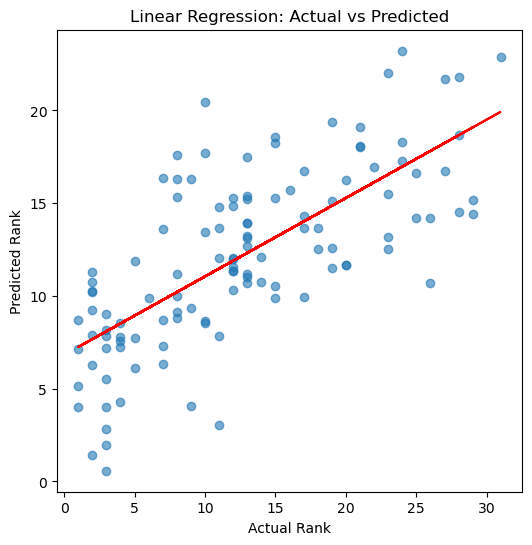

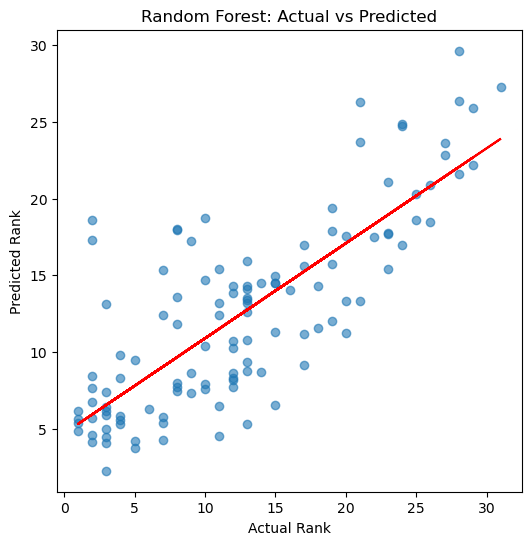

Linear Regression:
MAE: 4.498505548457861
MSE: 32.97619753288655
R2: 0.48449295950484583
Random Forest:
MAE: 3.807203389830508
MSE: 23.646205932203387
R2: 0.6303459297606258


In [7]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#train new model
newmodel = RandomForestRegressor(random_state=42)
newmodel.fit(xtrain, ytrain)
#predicition
newpred = newmodel.predict(xtest)

#pair predictions with team names for the test set
results = labels.loc[xtest.index].copy()
results['Actual'] = ytest
results['Predicted'] = newpred.round(1)
print(results.sort_values('Actual').head(15))

#graph function
def plotres(ytest, ypred, title):
    plt.figure(figsize=(6,6))
    #make scatter plot
    plt.scatter(ytest, ypred, alpha=0.6)
    #line
    m, b = np.polyfit(ytest, ypred, 1)
    plt.plot(ytest, m*ytest + b, color='red')
    plt.xlabel("Actual Rank")
    plt.ylabel("Predicted Rank")
    plt.title(title)
    plt.show()
#plot linear regression
plotres(ytest, ypred, "Linear Regression: Actual vs Predicted")
#plot random forest
plotres(ytest, newpred, "Random Forest: Actual vs Predicted")

#print linear regression analysis
print("Linear Regression:")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)
#random forest analysis
newmae = mean_absolute_error(ytest, newpred)
newmse = mean_squared_error(ytest, newpred)
newr2 = r2_score(ytest, newpred)
#print random forest analysis
print("Random Forest:")
print("MAE:", newmae)
print("MSE:", newmse)
print("R2:", newr2)

- Pairing predictions with teams shows the model consistently hedges toward mid table: every actual winner is predicted between 4.9 and 6.2. This is regression to the mean, showing that extreme predictions are penalised heavily when wrong, so the model rarely predicts the extremes.
- The random forest model resulted in a lower mean absolute error (3.81) than the linear regression (4.50), meaning its predictions are on average closer to the true rankings by about one position.
- The random forest model has a lower mean squared error (23.65) than linear regression (32.98), implying fewer large prediction errors.
- The random forest model has a higher R2 value (0.63) than the linear regression (0.48), meaning it explains more of the variation in world cup rankings.
- The scatter plots support this, showing random forest predictions gather closer to the diagonal line.
- Therefore it can be concluded that the random forest model is more reliable than the linear regression model for this task.

<b>Building a classifier to predict quarter final qualification:</b>

Accuracy: 0.8050847457627118
Precision: 0.7391304347826086
Recall: 0.7555555555555555
F1 Score: 0.7472527472527473


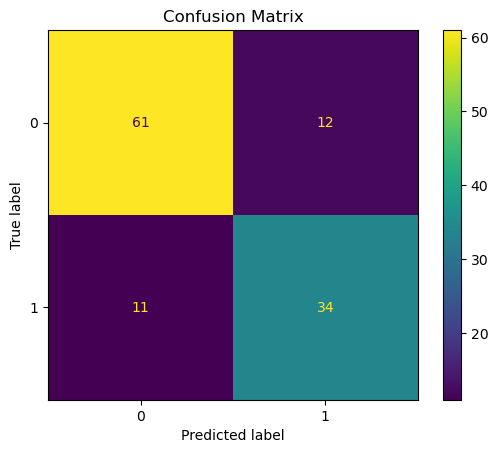

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

#make target, 1 is reached quarters, 0 did not
modeld['Reached_QuarterFinals'] = (modeld['WorldCup_Classification'] <= 8).astype(int)
#features
X = modeld.drop(columns=['WorldCup_Classification', 'Reached_QuarterFinals'])
#target
y = modeld['Reached_QuarterFinals']
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = RandomForestClassifier(random_state=42)
clf.fit(xtrain, ytrain)
#prediction
ypred = clf.predict(xtest)
#metrics
accuracy = accuracy_score(ytest, ypred)
precision = precision_score(ytest, ypred)
recall = recall_score(ytest, ypred)
f1 = f1_score(ytest, ypred)
#print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

#confusion matrix
cm = confusion_matrix(ytest, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- An accuracy of 0.81 shows that 81% of predictions were correct.
- Constantly predicting no would give the model a 62% baseline accuracy, since 38% of teams get to the quarter finals, so getting 81% is a great improvement.
- Precision of 0.74 shows that 74% of the teams the model predicted would qualify actually did.
- The recall of 0.76 shows that the model identifies 76% of the teams that make it to the quarter finals. The confusion matrix shows 11 false negatives, implying missed strong teams.

<b>Comparing with logistic regression and identifying the importance of the variables:</b>

In [9]:
from sklearn.linear_model import LogisticRegression

#train classifier
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(xtrain, ytrain)

#predictions
logpred = logmodel.predict(xtest)
#log regression metrics
logacc = accuracy_score(ytest, logpred)
logprec = precision_score(ytest, logpred)
logrec = recall_score(ytest, logpred)
logf1 = f1_score(ytest, logpred)
#print metrics
print("Logistic Regression:")
print("Accuracy:", logacc)
print("Precision:", logprec)
print("Recall:", logrec)
print("F1:", logf1)

#get feature importance
importances = clf.feature_importances_
imp = pd.DataFrame({'Feature': X.columns,'Importance': importances})
#sort by importance
imp = imp.sort_values(by='Importance', ascending=True)
print(imp.head(10))#least important
print(imp.tail(10)) #most important
#get least 3 imp features
leastimp = imp.head(3)['Feature'].tolist()
print("Removing:", leastimp)
#remove least imp
xreduced = X.drop(columns=leastimp)

#train test split
xtrainr, xtestr, ytrainr, ytestr = train_test_split(xreduced, y, test_size=0.2, random_state=42, stratify=y)
#retrain model
clfreduced = RandomForestClassifier(random_state=42)
clfreduced.fit(xtrainr, ytrainr)
#predict
ypredr = clfreduced.predict(xtestr)

#metrics after removal
accr = accuracy_score(ytestr, ypredr)
precr = precision_score(ytestr, ypredr)
recr = recall_score(ytestr, ypredr)
f1r = f1_score(ytestr, ypredr)
#print after removing features
print("Random forest metrics after removing features:")
print("Accuracy:", accr)
print("Precision:", precr)
print("Recall:", recr)
print("F1:", f1r)

Logistic Regression:
Accuracy: 0.8220338983050848
Precision: 0.8333333333333334
Recall: 0.6666666666666666
F1: 0.7407407407407407
                         Feature  Importance
20        Team_Continent_Oceania    0.000036
19  Team_Continent_North America    0.001859
25  Host_Continent_South America    0.002199
17           Team_Continent_Asia    0.002462
22           Host_Continent_Asia    0.003433
21  Team_Continent_South America    0.004497
24  Host_Continent_North America    0.006043
23         Host_Continent_Europe    0.006893
18         Team_Continent_Europe    0.013218
4            Losses_Last_4_Years    0.022092
                         Feature  Importance
15         Goal_Con_Last_4_Years    0.037250
13  Points_Per_Game_Last_4_Years    0.037696
16        Goal_Diff_Last_4_Years    0.037779
12  Goal_Difference_Last_4_Years    0.038846
14         Goal_Pro_Last_4_Years    0.040430
8            Group_Goals_Against    0.058683
10       Avg_Group_Goals_Against    0.065875
9            Av

- Logistic regression had a slightly higher accuracy than random forest (0.82 vs 0.81).
- Random forest had a higher recall than logistic regression (0.76 vs 0.67).
- Logistic regression had a higher precision than random forest (0.83 vs 0.74).
- Random forest had a slightly better F1 score than logistic regression (0.75 vs 0.74). F1 shows the balance between precision and recall.
- Overall, logistic regression is more accurate and more precise, random forest catches more actual qualifiers and scores better on F1, so the choice depends on whether false positives or missed qualifiers cost more.
- The most important features were related to attacking performance, like Avg_Group_Goal_Difference, Group_Goals_For, and Avg_Group_Goals_For, showing that attack is a key predictor of reaching the quarters. However, joined with the next two, Avg_Group_Goals_Against and Group_Goals_Against, 2 defensive features, the most accurate predictor of quarter final qualification would likely be overall goal difference moreso than purely offensive performance.
- The 3 least important features were Team_Continent_Oceania, Team_Continent_North America, and Host_Continent_South America.
- Removing these 3 features did change random forest's results; accuracy went from 0.81 to 0.82, precision from 0.74 to 0.80, and recall from 0.76 to 0.71. However, F1 was essentially unchanged, as both figures still round to 0.75. Given that the importances of these 3 features are under 0.003, these small changes are more consistent with noise than real effect.